In [1]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import load_model
from sklearn.metrics import (
    confusion_matrix, precision_score, recall_score,
    f1_score, roc_curve, roc_auc_score, classification_report
)

sns.set_style('whitegrid')
print('Libraries loaded successfully.')

Libraries loaded successfully.


In [12]:
import joblib

# --- Paths ---
MODEL_PATH = '../results/autoencoder_model.keras'
THRESHOLD_PATH = '../results/best_threshold.pkl'
SCALER_PATH = '../scaler/standard_scaler.pkl'
X_TEST_PATH = '../dataset/processed/X_test.csv'
Y_TEST_PATH = '../dataset/processed/y_test.csv'

# --- Load everything ---
model = load_model(MODEL_PATH)
threshold = joblib.load(THRESHOLD_PATH)
scaler = joblib.load(SCALER_PATH)

X_test_raw = pd.read_csv(X_TEST_PATH)
y_test = pd.read_csv(Y_TEST_PATH)

# Apply scaling ourselves, matching Member 2's process
X_test = pd.DataFrame(scaler.transform(X_test_raw), columns=X_test_raw.columns)

print('Model loaded:', model.input_shape, '->', model.output_shape)
print('Threshold:', threshold)
print('X_test shape:', X_test.shape)
print('y_test shape:', y_test.shape)
print('X_test min/max/mean:', X_test.values.min(), X_test.values.max(), X_test.values.mean())

Model loaded: (None, 42) -> (None, 42)
Threshold: 0.5330228854400606
X_test shape: (175341, 42)
y_test shape: (175341, 1)
X_test min/max/mean: -6.525895900699157 316.6326368709073 -0.1392942886192725


In [13]:
print(y_test.columns.tolist())
print(y_test.head())

['label']
   label
0      0
1      0
2      0
3      0
4      0


In [14]:
label_col = y_test.columns[0]
y_true = y_test[label_col].values

X_test_values = X_test.values
print('y_true unique values:', np.unique(y_true))
print('X_test_values shape:', X_test_values.shape)

y_true unique values: [0 1]
X_test_values shape: (175341, 42)


In [15]:
X_test_pred = model.predict(X_test_values)
reconstruction_error = np.mean(np.square(X_test_values - X_test_pred), axis=1)
y_pred = (reconstruction_error > threshold).astype(int)

print('Predictions generated.')
print('Predicted anomalies:', y_pred.sum(), '/', len(y_pred))

5480/5480 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step
Predictions generated.
Predicted anomalies: 172507 / 175341


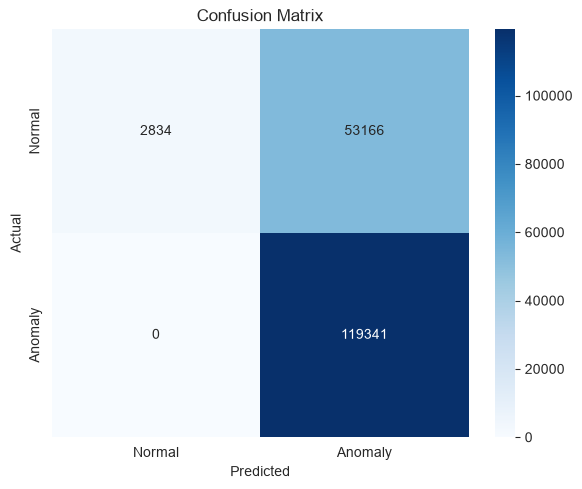

[[  2834  53166]
 [     0 119341]]


In [16]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

print(cm)

In [17]:
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f'Precision: {precision:.4f}')
print(f'Recall:    {recall:.4f}')
print(f'F1 Score:  {f1:.4f}')
print()
print(classification_report(y_true, y_pred, target_names=['Normal', 'Anomaly']))

Precision: 0.6918
Recall:    1.0000
F1 Score:  0.8178

              precision    recall  f1-score   support

      Normal       1.00      0.05      0.10     56000
     Anomaly       0.69      1.00      0.82    119341

    accuracy                           0.70    175341
   macro avg       0.85      0.53      0.46    175341
weighted avg       0.79      0.70      0.59    175341



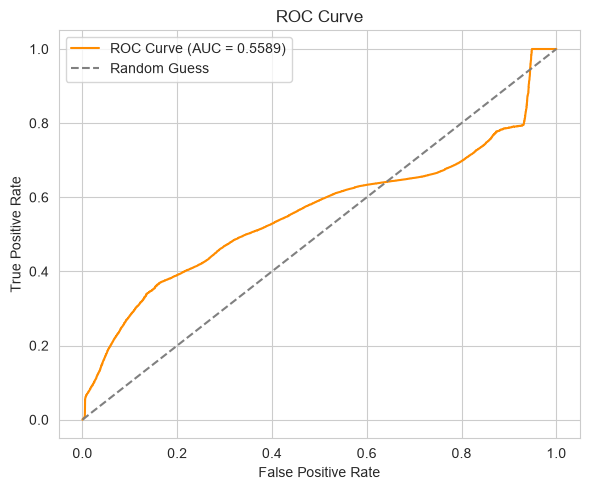

AUC Score: 0.5589


In [18]:
fpr, tpr, _ = roc_curve(y_true, reconstruction_error)
auc_score = roc_auc_score(y_true, reconstruction_error)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc_score:.4f})', color='darkorange')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()

print(f'AUC Score: {auc_score:.4f}')

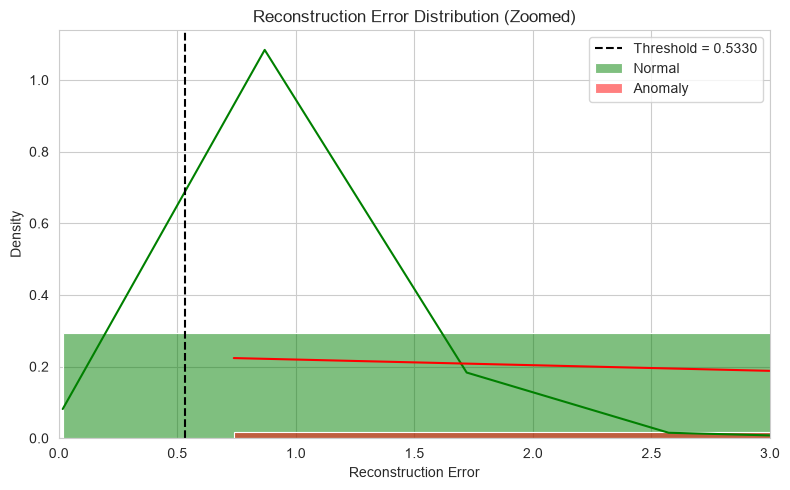

In [20]:
plt.figure(figsize=(8, 5))
sns.histplot(reconstruction_error[y_true == 0], bins=50, color='green', label='Normal', kde=True, stat='density', alpha=0.5)
sns.histplot(reconstruction_error[y_true == 1], bins=50, color='red', label='Anomaly', kde=True, stat='density', alpha=0.5)
plt.axvline(threshold, color='black', linestyle='--', label=f'Threshold = {threshold:.4f}')
plt.xlim(0, 3)  # zoom into the meaningful range near the threshold
plt.xlabel('Reconstruction Error')
plt.ylabel('Density')
plt.title('Reconstruction Error Distribution (Zoomed)')
plt.legend()
plt.tight_layout()
plt.savefig('reconstruction_error_distribution.png', dpi=150)
plt.show()